In [1]:
import numpy as np
import pandas as pd
import bayesflow as bf
import keras
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import benchmark.examples.gaussian.analysis.plot as PLT
import benchmark.examples.gaussian.analysis.mmd_err as MMD

INFO:bayesflow:Using backend 'jax'


In [24]:
# settings of this notebook
# num_dims=5
# num_obs=50
# likelihood_std=1
# student_df=5
# 1.mu=0,normal  2. mu=5, noraml 3. mu=0,student_t,df=5

/Users/mandyking/benchmark/benchmark/examples/gaussian/analysis/plot.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.10, 0.995, 0.95])


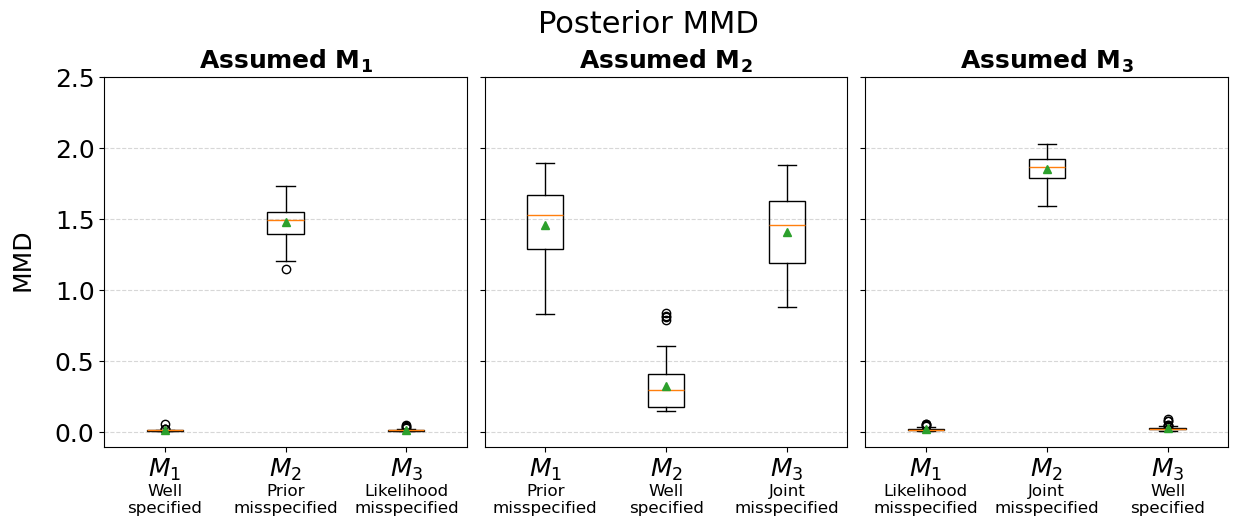

In [2]:
mmd_results = PLT.run_all_posterior_mmd_analysis()

PLT.build_metric_triptych(
    result_map=mmd_results,
    value_col="mmd",
    ylabel="MMD",
    suptitle="Posterior MMD",
    y_limits=(-0.1,2.5)
)

/Users/mandyking/benchmark/benchmark/examples/gaussian/analysis/plot.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.10, 0.995, 0.95])


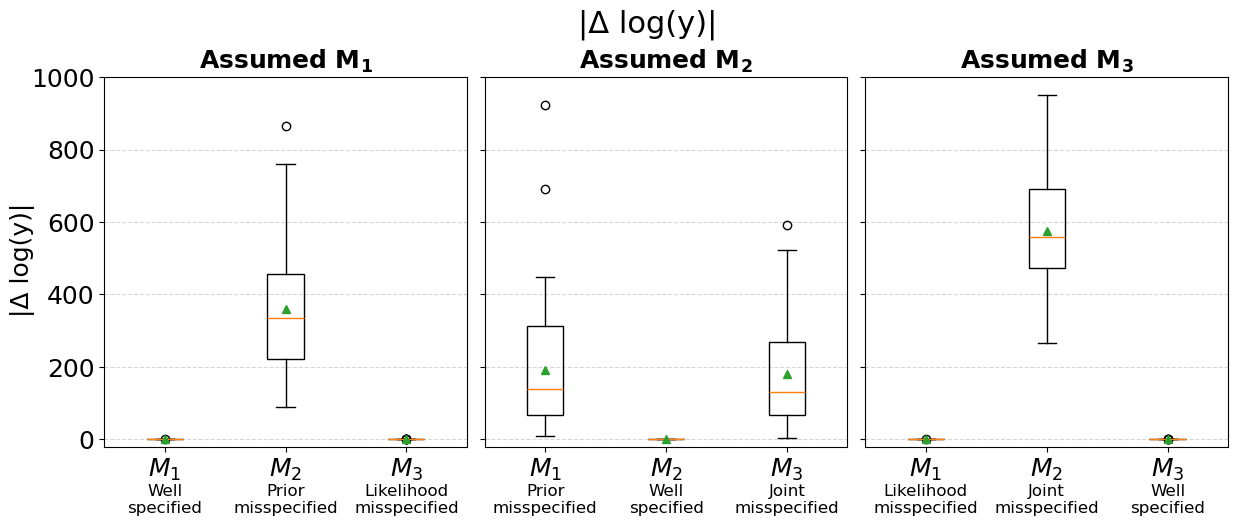

In [3]:
logml_results = PLT.run_all_logml_abs_error_analysis()
PLT.build_metric_triptych(
    result_map=logml_results,
    value_col="abs_error",
    ylabel="|Δ log(y)|",
    suptitle="|Δ log(y)|",
    y_limits=(-20,1000)
)


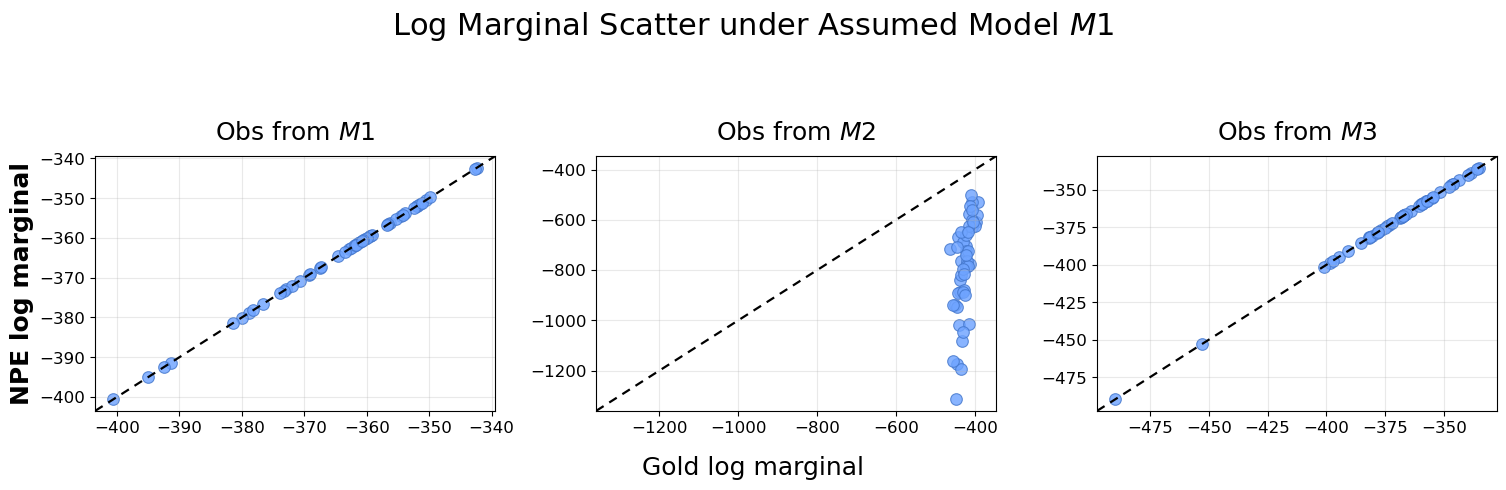

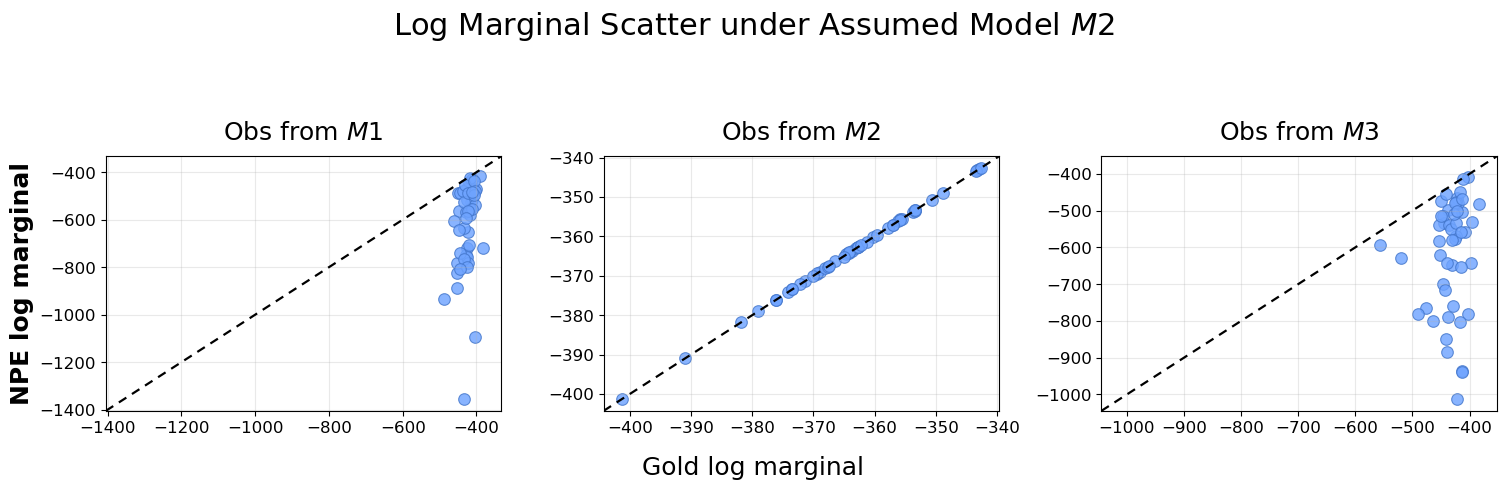

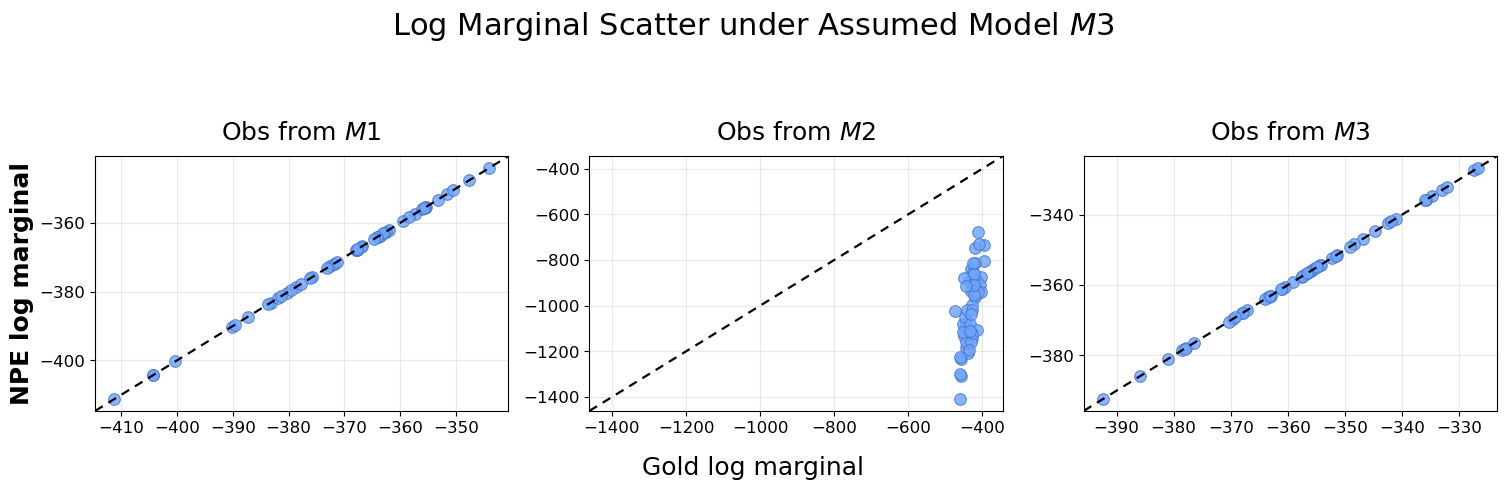

In [6]:
DATASETS_DIR = Path(
    "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets"
)

source_models = ["m1", "m2", "m3"]
assumed_models = ["m1", "m2", "m3"]

for assumed_model in assumed_models:
    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), sharex=False, sharey=False)

    for ax, source_model in zip(axes, source_models):
        dataset_path = DATASETS_DIR / f"{source_model}.pkl"

        with dataset_path.open("rb") as f:
            datasets = pickle.load(f)

        gold = np.array([float(item[f"gold_log_marginal_{assumed_model}"]) for item in datasets])
        npe = np.array([float(item[f"npe_log_marginal_{assumed_model}"]) for item in datasets])

        lo = min(gold.min(), npe.min())
        hi = max(gold.max(), npe.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)

        ax.scatter(
            gold, npe,
            s=70, alpha=0.82,
            color="#6FA4FF", edgecolor="#4477CC", linewidth=0.8,
        )
        ax.plot(
            [lo - pad, hi + pad],
            [lo - pad, hi + pad],
            "--", color="black", linewidth=1.6, dashes=(4, 3),
        )

        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.grid(alpha=0.28)
        ax.set_title(rf"Obs from ${source_model.upper()}$", fontsize=18, pad=12)
        ax.tick_params(labelsize=12)

    axes[0].set_ylabel("NPE log marginal", fontsize=18, fontweight="bold")
    fig.supxlabel("Gold log marginal", fontsize=18, y=0.04)
    fig.suptitle(
        rf"Log Marginal Scatter under Assumed Model ${assumed_model.upper()}$",
        fontsize=22,
        y=1.02,
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.92])
    plt.show()


<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
/var/folders/l7/b07js_755fb66rkjhmqb78d00000gn/T/ipykernel_91821/2296612972.py:6: SyntaxWarning: invalid escape sequence '\ '
  suptitle="Log marginal likelihood error using NPE vs.\ gold posterior samples",
/Users/mandyking/benchmark/benchmark/examples/gaussian/analysis/plot.py:617: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.10, 0.995, 0.92])


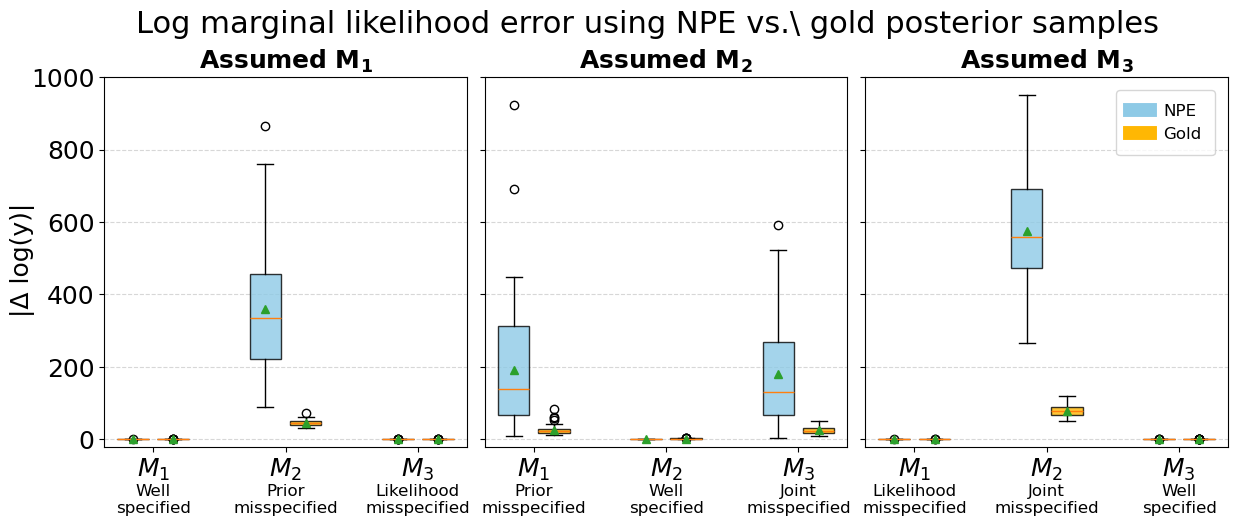

In [4]:
comparison_results = PLT.run_all_logml_comparison_analysis()
PLT.build_logml_comparison_triptych(
    result_map=comparison_results,
    value_col="abs_error",
    ylabel="|Δ log(y)|",
    suptitle="Log marginal likelihood error using NPE vs.\ gold posterior samples",
    y_limits=(-20,1000)
)



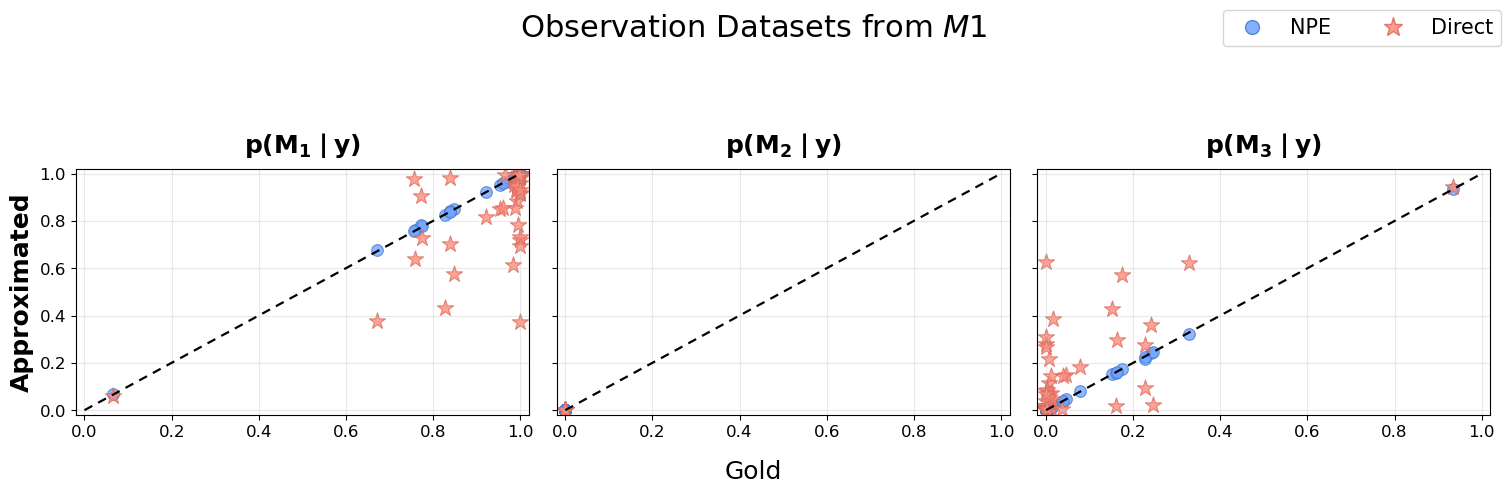

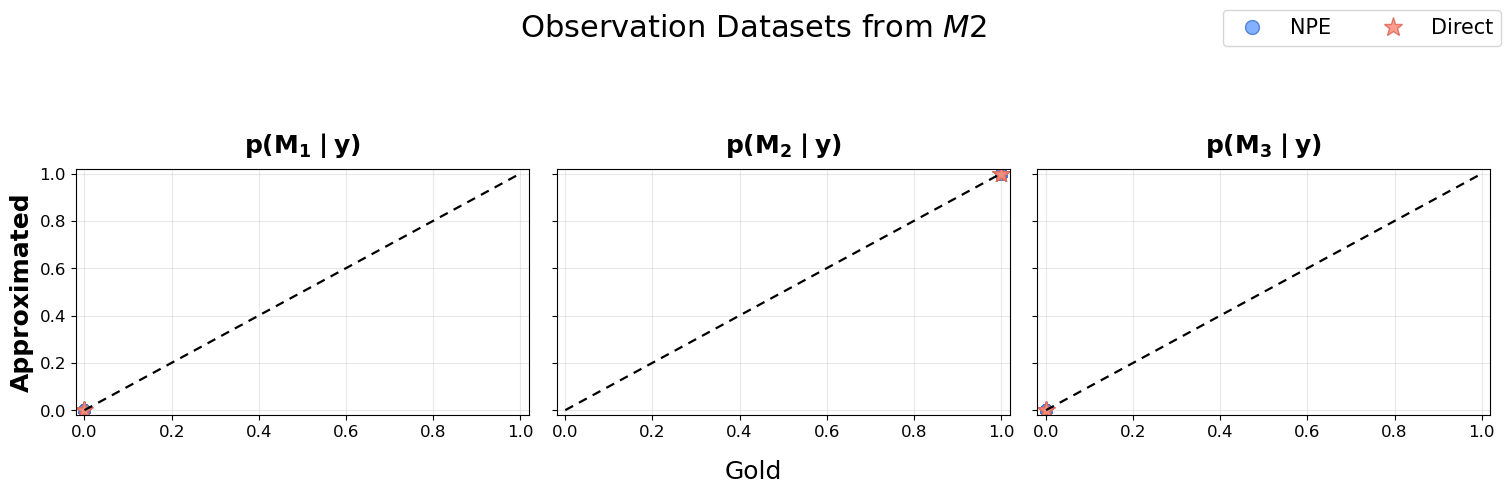

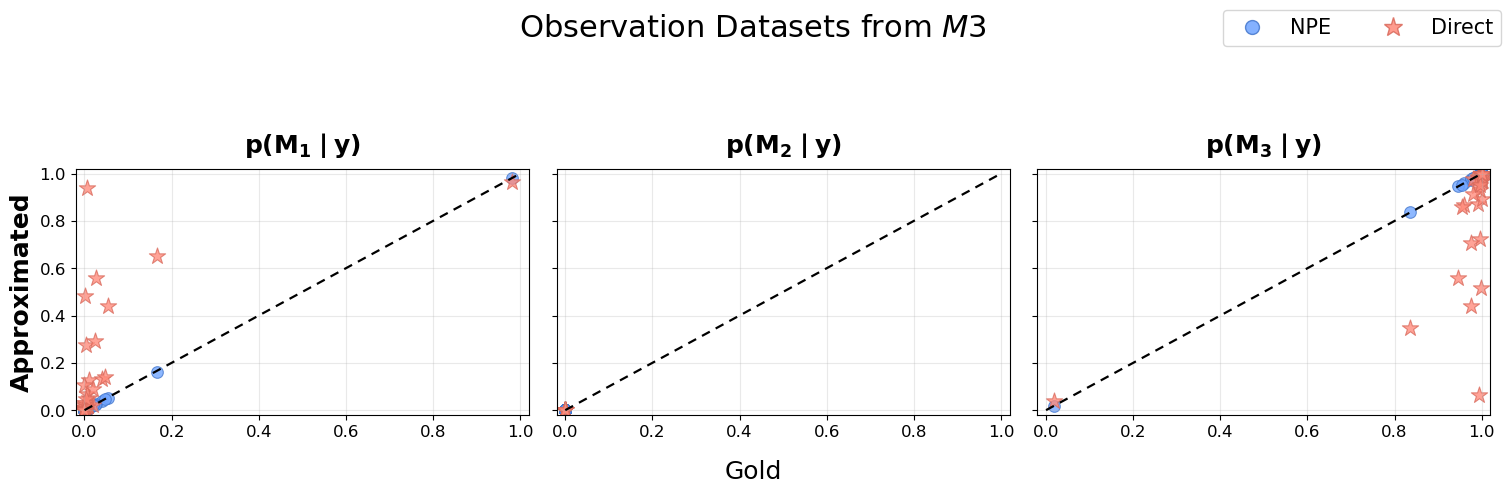

In [27]:
DATASETS_DIR = Path(
    "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets"
)

def normalize_prob(p, eps=1e-12):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0)
    return p / p.sum()

panel_titles = [
    r"$\mathbf{p(M_1\mid y)}$",
    r"$\mathbf{p(M_2\mid y)}$",
    r"$\mathbf{p(M_3\mid y)}$",
]

for source_model in ["m1", "m2", "m3"]:
    dataset_path = DATASETS_DIR / f"{source_model}.pkl"

    with dataset_path.open("rb") as f:
        datasets = pickle.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), sharex=True, sharey=True)

    for j, ax in enumerate(axes):
        gold = np.array([normalize_prob(item["p_gold"])[j] for item in datasets])
        npe = np.array([normalize_prob(item["p_npe"])[j] for item in datasets])
        direct = np.array([normalize_prob(item["p_direct"])[j] for item in datasets])

        ax.scatter(
            gold, npe,
            s=70, alpha=0.78,
            color="#6FA4FF", edgecolor="#4477CC", linewidth=0.8,
        )
        ax.scatter(
            gold, direct,
            s=150, alpha=0.78,
            marker="*", color="#FF8A7A", edgecolor="#D96A5C", linewidth=0.8,
        )

        ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1.6, dashes=(4, 3))
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.28)
        ax.set_title(panel_titles[j], fontsize=18, pad=12)
        ax.tick_params(labelsize=12)

    axes[0].set_ylabel("Approximated", fontsize=18, fontweight="bold")
    fig.supxlabel("Gold", fontsize=18, y=0.04)
    fig.suptitle(rf"Observation Datasets from ${source_model.upper()}$", fontsize=22, y=1.02)

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o", linestyle="None", markersize=10,
            markerfacecolor="#6FA4FF", markeredgecolor="#4477CC",
            label="NPE", alpha=0.85
        ),
        Line2D(
            [0], [0],
            marker="*", linestyle="None", markersize=14,
            markerfacecolor="#FF8A7A", markeredgecolor="#D96A5C",
            label="Direct", alpha=0.85
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper right",
        bbox_to_anchor=(0.98, 1.05),
        ncol=2,
        frameon=True,
        fontsize=15,
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.9])
    plt.show()


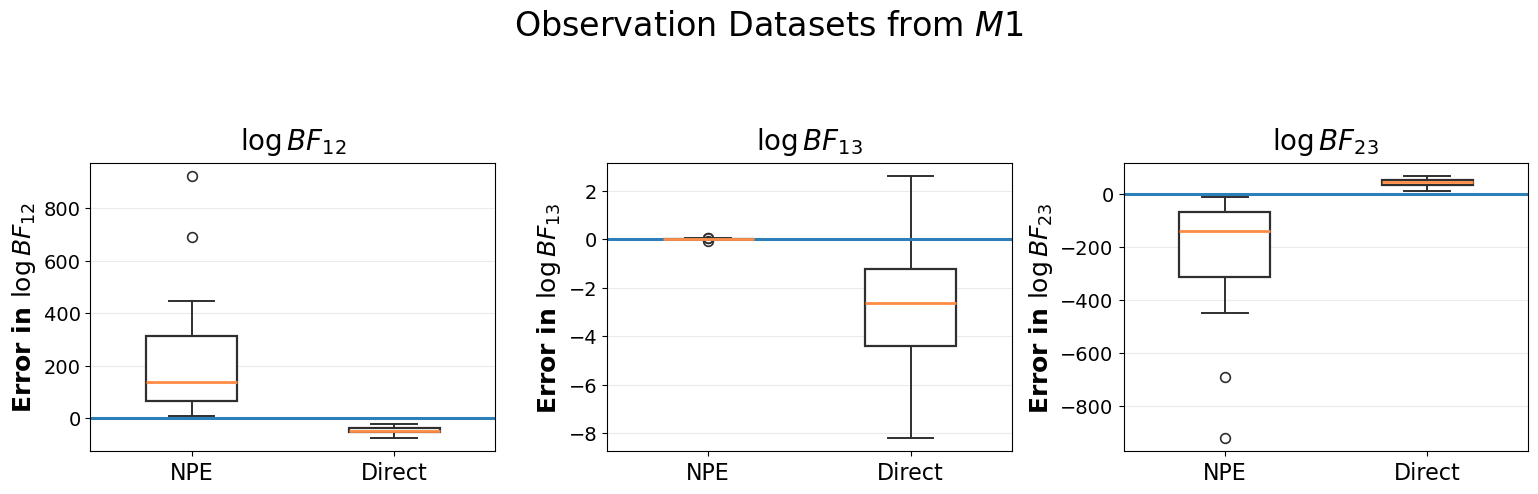

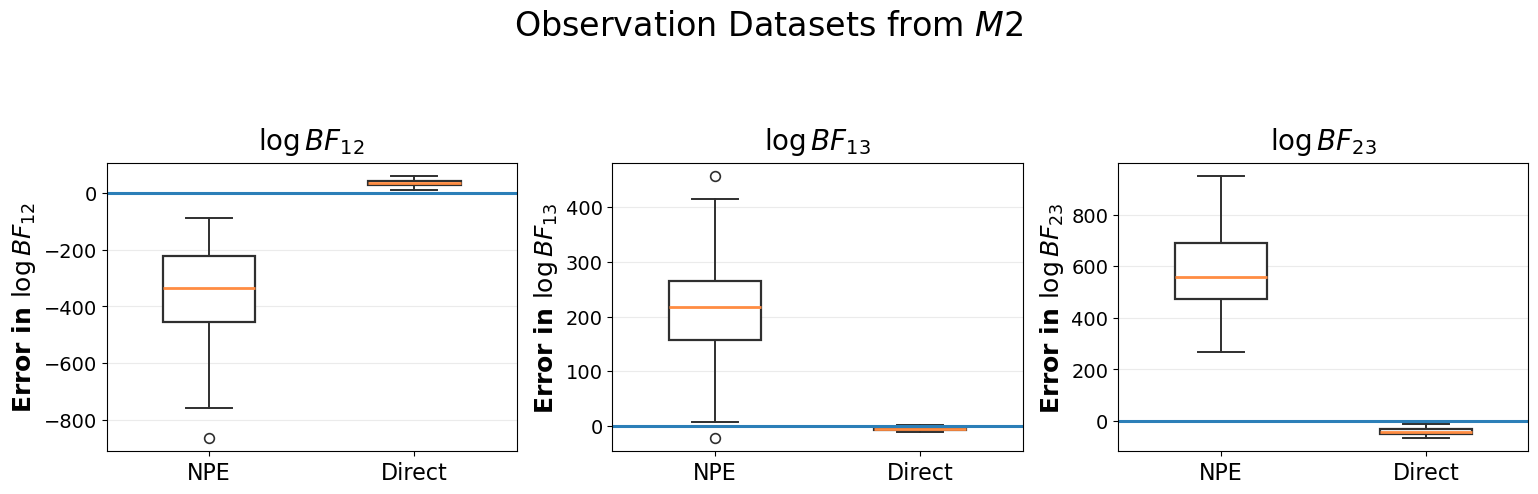

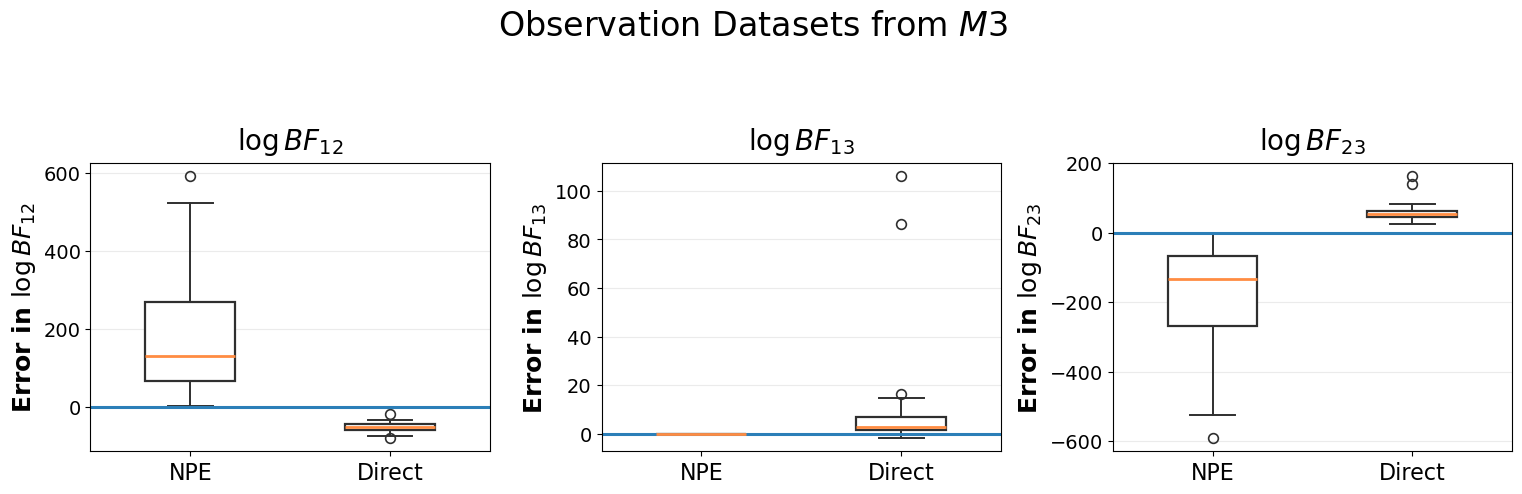

In [10]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "benchmark").exists():
            return candidate
    raise RuntimeError("Could not locate project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
GAUSSIAN_DIR = PROJECT_ROOT / "benchmark" / "examples" / "gaussian"
DATASETS_DIR = GAUSSIAN_DIR / "results" / "datasets"

def load_datasets(source_model: str):
    with (DATASETS_DIR / f"{source_model}.pkl").open("rb") as f:
        return pickle.load(f)
    
pairs = ["12", "13", "23"]
source_models = ["m1", "m2", "m3"]

line_color = "#2C7FB8"
box_edge = "#2F2F2F"
median_color = "#FF8C42"
grid_color = "#C7C7C7"

for source_model in source_models:
    datasets = load_datasets(source_model)

    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), sharex=False)

    for ax, pair in zip(axes, pairs):
        npe_err = [
            float(item[f"logBF_{pair}_npe"]) - float(item[f"logBF_{pair}_gold"])
            for item in datasets
        ]
        direct_err = [
            float(item[f"logBF_{pair}_direct"]) - float(item[f"logBF_{pair}_gold"])
            for item in datasets
        ]

        ax.boxplot(
            [npe_err, direct_err],
            tick_labels=["NPE", "Direct"],
            widths=0.45,
            patch_artist=True,
            boxprops={
                "facecolor": "white",
                "edgecolor": box_edge,
                "linewidth": 1.6,
            },
            medianprops={
                "color": median_color,
                "linewidth": 2.0,
            },
            whiskerprops={
                "color": box_edge,
                "linewidth": 1.4,
            },
            capprops={
                "color": box_edge,
                "linewidth": 1.4,
            },
            flierprops={
                "marker": "o",
                "markerfacecolor": "none",
                "markeredgecolor": box_edge,
                "markersize": 7,
                "markeredgewidth": 1.2,
            },
        )

        ax.axhline(0.0, color=line_color, linewidth=2.2)
        ax.set_title(rf"$\log BF_{{{pair}}}$", fontsize=20, pad=10)
        ax.set_ylabel(rf"Error in $\log BF_{{{pair}}}$", fontsize=18, fontweight="bold")
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(axis="y", color=grid_color, alpha=0.35)

    fig.suptitle(rf"Observation Datasets from ${source_model.upper()}$", fontsize=24, y=1.03)
    fig.tight_layout(rect=[0.01, 0.01, 0.99, 0.92])
    plt.show()




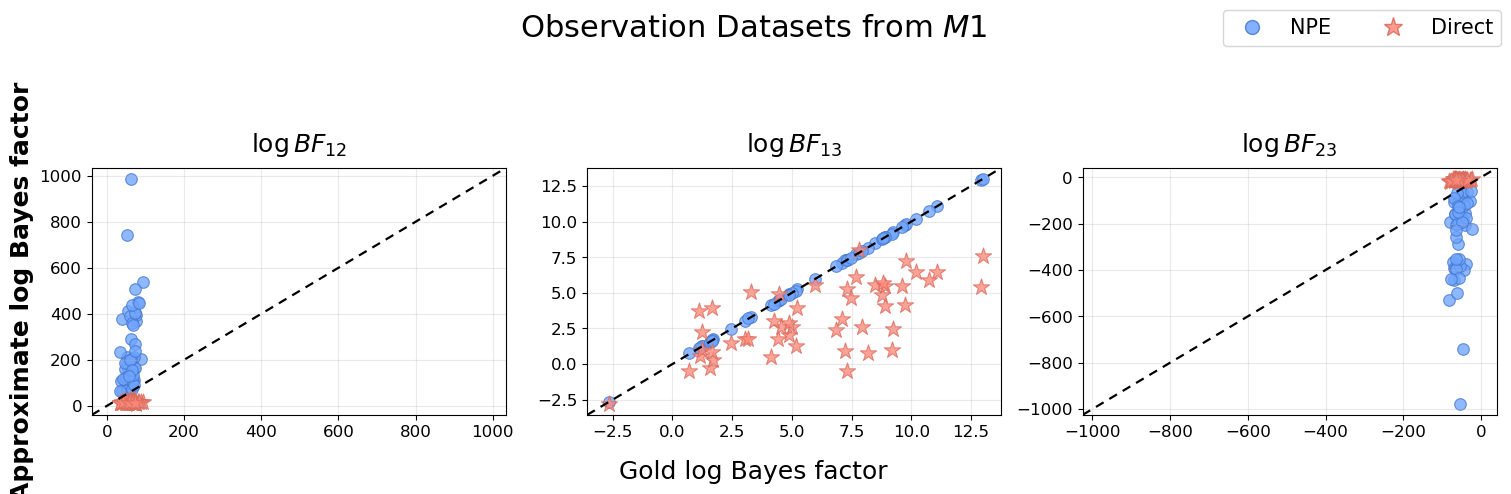

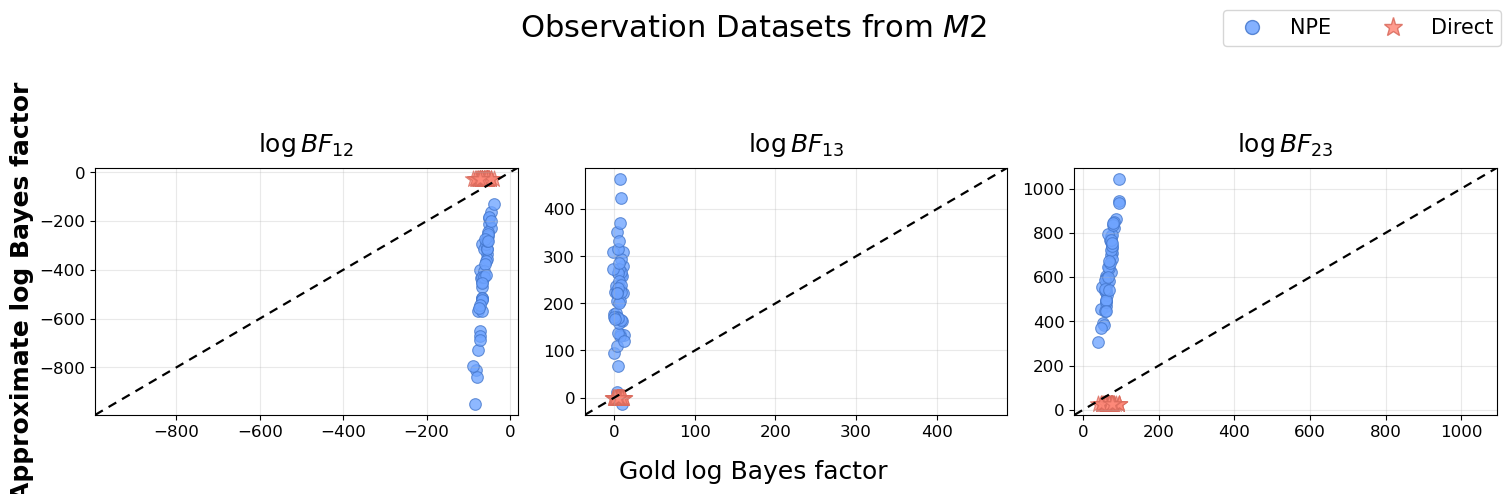

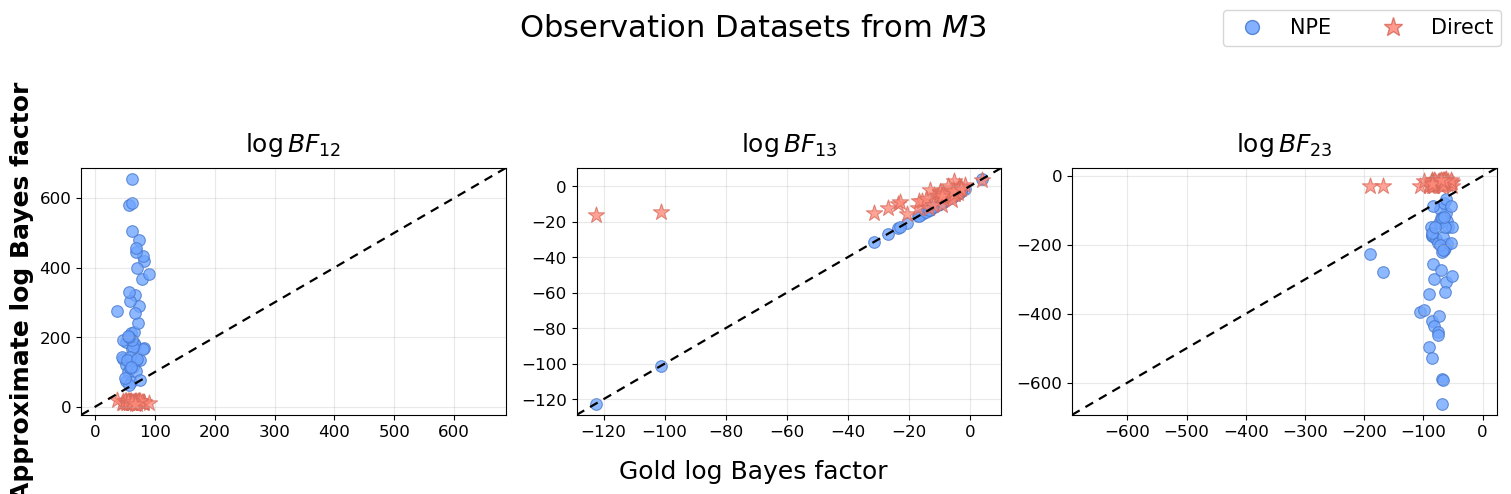

In [32]:
DATASETS_DIR = Path(
    "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets"
)

pairs = ["12", "13", "23"]

for source_model in ["m1", "m2", "m3"]:
    dataset_path = DATASETS_DIR / f"{source_model}.pkl"

    with dataset_path.open("rb") as f:
        datasets = pickle.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), sharex=False, sharey=False)

    for ax, pair in zip(axes, pairs):
        gold = np.array([float(item[f"logBF_{pair}_gold"]) for item in datasets])
        npe = np.array([float(item[f"logBF_{pair}_npe"]) for item in datasets])
        direct = np.array([float(item[f"logBF_{pair}_direct"]) for item in datasets])

        lo = min(gold.min(), npe.min(), direct.min())
        hi = max(gold.max(), npe.max(), direct.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)

        ax.scatter(
            gold, npe,
            s=70, alpha=0.78,
            color="#6FA4FF", edgecolor="#4477CC", linewidth=0.8,
            label="NPE",
        )
        ax.scatter(
            gold, direct,
            s=150, alpha=0.78,
            marker="*", color="#FF8A7A", edgecolor="#D96A5C", linewidth=0.8,
            label="Direct",
        )

        ax.plot(
            [lo - pad, hi + pad],
            [lo - pad, hi + pad],
            "--", color="black", linewidth=1.6, dashes=(4, 3),
        )

        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.grid(alpha=0.28)
        ax.set_title(rf"$\log BF_{{{pair}}}$", fontsize=18, pad=12)
        ax.tick_params(labelsize=12)

    axes[0].set_ylabel("Approximate log Bayes factor", fontsize=18, fontweight="bold")
    fig.supxlabel("Gold log Bayes factor", fontsize=18, y=0.04)
    fig.suptitle(rf"Observation Datasets from ${source_model.upper()}$", fontsize=22, y=1.02)

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="None", markersize=10,
               markerfacecolor="#6FA4FF", markeredgecolor="#4477CC", label="NPE", alpha=0.85),
        Line2D([0], [0], marker="*", linestyle="None", markersize=14,
               markerfacecolor="#FF8A7A", markeredgecolor="#D96A5C", label="Direct", alpha=0.85),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper right",
        bbox_to_anchor=(0.98, 1.05),
        ncol=2,
        frameon=True,
        fontsize=15,
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.9])
    plt.show()


In [9]:
source_models = ["m1", "m2", "m3"]
prob_keys = ["p_gold", "p_npe", "p_direct"]

rows = []
for source_model in source_models:
    datasets = load_datasets(source_model)

    for prob_key in prob_keys:
        arr = np.array([np.asarray(item[prob_key], dtype=float) for item in datasets])
        mean_vec = arr.mean(axis=0)

        rows.append(
            {
                "source_model": source_model,
                "probability": prob_key,
                "mean_M1": mean_vec[0].round(3),
                "mean_M2": mean_vec[1].round(3),
                "mean_M3": mean_vec[2].round(3),
                "sum": mean_vec.sum().round(3),
            }
        )

mean_df = pd.DataFrame(rows)
mean_df


,source_model,probability,mean_M1,mean_M2,mean_M3,sum
0,m1,p_gold,0.937,0.0,0.063,1.0
1,m1,p_npe,0.937,0.0,0.063,1.0
2,m1,p_direct,0.858,0.0,0.142,1.0
3,m2,p_gold,0.000,1.0,0.000,1.0
4,m2,p_npe,0.000,1.0,0.000,1.0
5,m2,p_direct,0.000,1.0,0.000,1.0
6,m3,p_gold,0.029,0.0,0.971,1.0
7,m3,p_npe,0.029,0.0,0.971,1.0
8,m3,p_direct,0.112,0.0,0.888,1.0
